# Sesión 8: LSTM+TDA v2 + Variables Exógenas — Ablation Study

## Objetivo
Mejorar el modelo LSTM+TDA de Sesión 6 incorporando:
1. **TDA v2**: homología H₀/H₁/H₂, distancia Wasserstein entre ventanas, conteo H₁ significativo
2. **Variables exógenas**: S&P500, CPI, Fed Funds, USD Index, PPI Frutas, PPI Verduras, WTI, PPI Agrícola
3. **Arquitectura**: LSTM + MultiHead Attention
4. **Ablation**: 7 modelos comparados en mismo conjunto de prueba

**Fuente:** WPUSI01102B.csv (215 puntos, Jun 2008 – Abr 2026)

In [115]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm
from fredapi import Fred
import yfinance as yf

from gtda.time_series import SingleTakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PersistenceEntropy, Amplitude, BettiCurve
from persim import wasserstein as wasserstein_dist

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import shap

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, Input,
    MultiHeadAttention, LayerNormalization, Add
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

tf.random.set_seed(42)
np.random.seed(42)

# ── API ───────────────────────────────────────────────────
FRED_KEY = "f439f2437c523c42fef599c60082b245"   # do not commit
fred = Fred(api_key=FRED_KEY)

# ── TDA constants ─────────────────────────────────────────
W   = 36    # rolling window (months)
D   = 6     # Takens dimension
TAU = 3     # Takens time delay
L   = 12    # LSTM lookback (timesteps)

EMBED_PTS = W - (D - 1) * TAU   # = 21

print(f"TF {tf.__version__} | LGB {lgb.__version__}")
print(f"Embedding points per window: {EMBED_PTS}")

TF 2.21.0 | LGB 4.6.0
Embedding points per window: 21


## §1 — Descarga y Alineación de Variables Exógenas

In [116]:
# ── Target series ─────────────────────────────────────────
df_target = pd.read_csv('WPUSI01102B.csv', parse_dates=['observation_date'])
df_target = df_target.set_index('observation_date').sort_index()
prices    = df_target['WPUSI01102B'].values.astype(float)
dates     = df_target.index
n_total   = len(prices)

START = dates[0]
END   = dates[-1]
print(f"Target: {n_total} points  {START.date()} → {END.date()}")

# ── FRED series ───────────────────────────────────────────
FRED_CODES = {
    'CPI':       'CPIAUCSL',
    'FedFunds':  'FEDFUNDS',
    'USD':       'DTWEXBGS',
    'PPI_Fruit': 'WPU01110301',
    'PPI_Veg':   'WPS011',
    'Oil_WTI':   'DCOILWTICO',
    'Agri_PPI':  'PPIFAS',
}

frames = {}
for name, code in FRED_CODES.items():
    try:
        s = fred.get_series(code,
                            observation_start=START - pd.DateOffset(months=2),
                            observation_end=END)
        frames[name] = s.resample('MS').last()
        print(f"  ✓ {name} ({code}): {len(s)} raw pts")
    except Exception as e:
        print(f"  ✗ {name} ({code}): {e}")

# ── S&P500 via yfinance ───────────────────────────────────
try:
    sp500_raw = yf.download('^GSPC',
                            start=START - pd.DateOffset(months=2),
                            end=END + pd.DateOffset(months=2),
                            progress=False)
    # Handle both old and new yfinance column formats
    if isinstance(sp500_raw.columns, pd.MultiIndex):
        sp500_raw = sp500_raw[('Close', '^GSPC')]
    else:
        sp500_raw = sp500_raw['Close']
    frames['SP500'] = sp500_raw.resample('MS').last()
    print(f"  ✓ SP500: {len(sp500_raw)} raw pts")
except Exception as e:
    print(f"  ✗ SP500 (^GSPC): {e}")

# ── Align to target index ─────────────────────────────────
df_exog = pd.DataFrame(frames).reindex(dates)
df_exog = df_exog.ffill(limit=2)      # forward-fill max 2 months

# Exclude series with >10% missing
miss = df_exog.isnull().mean()
exclude = miss[miss > 0.10].index.tolist()
if exclude:
    print(f"\nWARNING — excluding series >10% missing: {exclude}")
    df_exog = df_exog.drop(columns=exclude)

# Remaining missing → backfill then 0
df_exog = df_exog.bfill(limit=2).fillna(0)
assert df_exog.index.equals(dates), "Exogenous index mismatch with target dates!"

N_EXOG = df_exog.shape[1]
print(f"\ndf_exog shape: {df_exog.shape}  (kept {N_EXOG} exogenous series)")
print(f"Missing after fill: {df_exog.isnull().sum().sum()}")
df_exog.head(3)

Target: 215 points  2008-06-01 → 2026-04-01
  ✗ CPI (CPIAUCSL): <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)>
  ✗ FedFunds (FEDFUNDS): <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)>
  ✗ USD (DTWEXBGS): <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)>
  ✗ PPI_Fruit (WPU01110301): <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)>
  ✗ PPI_Veg (WPS011): <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)>
  ✗ Oil_WTI (DCOILWTICO): <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1006)>
  ✗ Agri_PPI (PPIFAS): <urlopen error [S

,SP500
observation_date,
2008-06-01,1280.000000
2008-07-01,1267.380005
2008-08-01,1282.829956


## §2 — Extracción de Características TDA v2 (W=36, H₀/H₁/H₂)

Para cada mes `t ∈ [35, 214]`:
- Embedding de Takens sobre `prices[t-35:t+1]` → shape (21, 6)
- VietorisRips con H₀, H₁, H₂
- 157 características: price(t) + entropías + amplitudes + max H₁ + BettiCurve + Wasserstein + H₁ count + raw embedding
- Cache en `F_tda_v2_features.npy`

In [117]:
CACHE = 'F_tda_v2_features.npy'
N_BINS = 10

if os.path.exists(CACHE):
    F = np.load(CACHE)
    print(f"Loaded from cache: {F.shape}")
else:
    # ── Instantiate transformers ───────────────────────────
    STE = SingleTakensEmbedding(parameters_type="fixed", dimension=D, time_delay=TAU)
    VR  = VietorisRipsPersistence(homology_dimensions=[0, 1, 2], n_jobs=-1)
    PE  = PersistenceEntropy(nan_fill_value=0.0)
    AMP = Amplitude()
    BC  = BettiCurve(n_bins=N_BINS)

    feature_list = []
    prev_diag_h0 = None   # for Wasserstein(t vs t-1)
    prev_diag_h1 = None

    all_h1_pers = []

    for t in tqdm(range(W - 1, n_total), desc="TDA v2"):
        window    = prices[t - W + 1 : t + 1]            # (36,)
        embedding = STE.fit_transform(window)              # (21, 6)
        emb_3d    = embedding[np.newaxis, :, :]           # (1, 21, 6)
        diagrams  = VR.fit_transform(emb_3d)              # (1, n_pts, 3)

        # PersistenceEntropy H0, H1, H2
        pe = PE.fit_transform(diagrams)[0]                # (3,)

        # Amplitude H0, H1, H2
        amp = AMP.fit_transform(diagrams)[0]              # (3,)

        # Max H1 persistence
        diag = diagrams[0]                                # (n_pts, 3)
        h1_pts = diag[diag[:, 2] == 1][:, :2]
        h1_pts = h1_pts[np.isfinite(h1_pts).all(axis=1)]
        h1_pers = h1_pts[:, 1] - h1_pts[:, 0] if len(h1_pts) > 0 else np.array([0.])
        max_h1  = float(h1_pers.max()) if len(h1_pers) > 0 else 0.0
        all_h1_pers.append(h1_pers)

        # BettiCurve H0 + H1 only (20 bins)
        bc = BC.fit_transform(diagrams)[0]                # (3, 10) → H0, H1, H2
        betti = np.concatenate([bc[0], bc[1]])            # (20,)

        # Wasserstein distance vs previous diagram
        h0_pts = diag[diag[:, 2] == 0][:, :2]
        h0_pts = h0_pts[np.isfinite(h0_pts).all(axis=1)]
        if prev_diag_h0 is None:
            w_h0, w_h1 = 0.0, 0.0
        else:
            w_h0 = wasserstein_dist(h0_pts, prev_diag_h0) if len(h0_pts)>0 and len(prev_diag_h0)>0 else 0.0
            w_h1 = wasserstein_dist(h1_pts, prev_diag_h1) if len(h1_pts)>0 and len(prev_diag_h1)>0 else 0.0
        prev_diag_h0 = h0_pts.copy()
        prev_diag_h1 = h1_pts.copy()

        # Raw Takens embedding flattened (21*6=126)
        emb_flat = embedding.flatten()                    # (126,)

        feat = np.concatenate([
            [prices[t]],          # 1: price(t)
            pe,                   # 3: PE H0,H1,H2
            amp,                  # 3: AMP H0,H1,H2
            [max_h1],             # 1: max H1
            betti,                # 20: Betti H0+H1
            [w_h0, w_h1],         # 2: Wasserstein
            [0.0],                # 1: H1 count (placeholder, will be replaced post-hoc)
            emb_flat,             # 126: raw Takens
        ])
        feature_list.append(feat)

    F = np.array(feature_list)   # (180, 157)

    # Replace H1 count (col 30) with threshold-based count
    all_pers_flat = np.concatenate(all_h1_pers) if all_h1_pers else np.array([0.])
    p75 = np.percentile(all_pers_flat, 75) if len(all_pers_flat) > 0 else 0.0
    H1_COUNT_COL = 1 + 3 + 3 + 1 + 20 + 2  # = 30
    for i, h1_pers_i in enumerate(all_h1_pers):
        F[i, H1_COUNT_COL] = float(np.sum(h1_pers_i > p75))

    np.save(CACHE, F)
    print(f"Saved {CACHE}: {F.shape}")

print(f"F shape: {F.shape}  — expected (180, 157)")
assert F.shape == (n_total - W + 1, 157), f"Shape mismatch: {F.shape}"
assert np.isfinite(F).all(), "F contains inf or NaN"
print("Sanity check passed ✓")

Loaded from cache: (180, 157)
F shape: (180, 157)  — expected (180, 157)
Sanity check passed ✓


## §3 — Construcción de Secuencias LSTM + División + Normalización

Ventana LSTM de L=12 pasos sobre F (TDA features) + exógenas.  
Target: precio del mes siguiente a la última ventana.

In [118]:
# Align exogenous to TDA time axis (F starts at t=W-1=35)
exog_vals = df_exog.values[W - 1:]          # (180, N_EXOG)
assert len(exog_vals) == len(F), "Length mismatch exog vs F"

# Combined feature matrix: TDA + exog
F_full = np.concatenate([F, exog_vals], axis=1)   # (180, 157+N_EXOG)
N_FEATURES = F_full.shape[1]
print(f"N_FEATURES = {N_FEATURES}  (157 TDA + {N_EXOG} exog)")

# Target: prices offset by W-1 (F[i] corresponds to prices[W-1+i])
prices_sub = prices[W - 1:]                 # (180,)

# Build LSTM sequences: X[i] = F_full[i:i+L], y[i] = prices_sub[i+L]
X_list, y_list = [], []
for i in range(len(F_full) - L):
    X_list.append(F_full[i : i + L])        # (12, N_FEATURES)
    y_list.append(prices_sub[i + L])        # scalar

X = np.array(X_list)   # (n_seq, 12, N_FEATURES)
y = np.array(y_list)   # (n_seq,)
n_seq = len(X)
print(f"Sequences: X={X.shape}, y={y.shape}")

# Chronological 70/15/15 split
n_train = int(n_seq * 0.70)
n_val   = int(n_seq * 0.15)
n_test  = n_seq - n_train - n_val

X_train, y_train = X[:n_train],             y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],        y[n_train+n_val:]
print(f"Train={len(X_train)}, Val={len(X_val)}, Test={len(X_test)}")

# Test dates (for plotting later)
test_start_idx = W - 1 + n_train + n_val + L
test_dates     = dates[test_start_idx : test_start_idx + n_test]

# Normalize X — fit on train only
scaler_X = StandardScaler()
X_train_s = scaler_X.fit_transform(X_train.reshape(-1, N_FEATURES)).reshape(X_train.shape)
X_val_s   = scaler_X.transform(X_val.reshape(-1, N_FEATURES)).reshape(X_val.shape)
X_test_s  = scaler_X.transform(X_test.reshape(-1, N_FEATURES)).reshape(X_test.shape)

# Normalize y — fit on train only
scaler_y = StandardScaler()
y_train_s = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_s   = scaler_y.transform(y_val.reshape(-1, 1)).flatten()
y_test_s  = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

print("Normalization done \u2713")

N_FEATURES = 158  (157 TDA + 1 exog)
Sequences: X=(168, 12, 158), y=(168,)
Train=117, Val=25, Test=26
Normalization done ✓


In [119]:
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"── {name} ────────────────────────────────────────")
    print(f"  MAE : {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²  : {r2:.4f}")
    return {'Model': name, 'MAE': mae, 'RMSE': rmse, 'R²': r2}

results = []   # accumulate dicts for final table

# ── Models 1 & 3: copy from Sesion-6 ─────────────────
results.append({'Model': 'RF (Sesion-6 baseline)',   'MAE': 38.7105, 'RMSE': 48.9645, 'R²': 0.2647})
results.append({'Model': 'LSTM+TDA v1 (Sesion-6)',   'MAE': 29.4890, 'RMSE': 37.5017, 'R²': 0.5687})
print("Models 1 & 3 copied from Sesion-6 ✓")

Models 1 & 3 copied from Sesion-6 ✓


## §4 — Ablation LSTM Variants

### Modelo 2: LSTM Puro (solo precios)
### Modelo 4: LSTM + Exógenas (sin TDA)
### Modelo 5: LSTM + TDA v2 (sin exógenas, sin attention)

In [120]:
def train_lstm(model, X_tr, y_tr, X_v, y_v, patience=30):
    cb = [
        EarlyStopping(monitor='val_loss', patience=patience,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', patience=10,
                          factor=0.5, verbose=0, min_lr=1e-5)
    ]
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='mae', metrics=['mse'])
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=300, batch_size=16,
        callbacks=cb, verbose=0
    )
    return history

In [121]:
# ── Model 2: LSTM puro ────────────────────────────────────
# Uses only raw price sequence, no TDA, no exog
# X shape: (n, 12, 1)
prices_sub_arr = prices[W - 1:]
X2_list, y2_list = [], []
for i in range(len(prices_sub_arr) - L):
    X2_list.append(prices_sub_arr[i : i + L].reshape(-1, 1))
    y2_list.append(prices_sub_arr[i + L])
X2 = np.array(X2_list)   # (n_seq, 12, 1)
y2 = np.array(y2_list)

X2_train, y2_train = X2[:n_train], y2[:n_train]
X2_val,   y2_val   = X2[n_train:n_train+n_val], y2[n_train:n_train+n_val]
X2_test,  y2_test  = X2[n_train+n_val:], y2[n_train+n_val:]

sc2_X = StandardScaler()
X2_train_s = sc2_X.fit_transform(X2_train.reshape(-1,1)).reshape(X2_train.shape)
X2_val_s   = sc2_X.transform(X2_val.reshape(-1,1)).reshape(X2_val.shape)
X2_test_s  = sc2_X.transform(X2_test.reshape(-1,1)).reshape(X2_test.shape)

sc2_y = StandardScaler()
y2_train_s = sc2_y.fit_transform(y2_train.reshape(-1,1)).flatten()
y2_val_s   = sc2_y.transform(y2_val.reshape(-1,1)).flatten()

m2 = Sequential([
    LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1,
         input_shape=(L, 1)),
    LSTM(32, dropout=0.2, recurrent_dropout=0.1),
    Dense(16, activation='relu'),
    Dense(1)
], name='LSTM_puro')

train_lstm(m2, X2_train_s, y2_train_s, X2_val_s, y2_val_s)

y2_pred = sc2_y.inverse_transform(m2.predict(X2_test_s)).flatten()
results.append(evaluate('LSTM puro (Modelo 2)', y2_test, y2_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
── LSTM puro (Modelo 2) ────────────────────────────────────────
  MAE : 34.3823
  RMSE: 46.3652
  R²  : 0.3407


In [122]:
# ── Model 4: LSTM + Exógenas, sin TDA ────────────────────
# Feature vector: [price(t)] + exog_vals[t] = 1 + N_EXOG features
price_col = prices[W-1:].reshape(-1, 1)             # (180, 1)
F4_full   = np.concatenate([price_col, exog_vals], axis=1)  # (180, 1+N_EXOG)
N4 = F4_full.shape[1]

X4_list, y4_list = [], []
for i in range(len(F4_full) - L):
    X4_list.append(F4_full[i : i + L])
    y4_list.append(prices_sub[i + L])
X4 = np.array(X4_list)
y4 = np.array(y4_list)

X4_train, y4_train = X4[:n_train], y4[:n_train]
X4_val,   y4_val   = X4[n_train:n_train+n_val], y4[n_train:n_train+n_val]
X4_test,  y4_test  = X4[n_train+n_val:], y4[n_train+n_val:]

sc4_X = StandardScaler()
X4_train_s = sc4_X.fit_transform(X4_train.reshape(-1,N4)).reshape(X4_train.shape)
X4_val_s   = sc4_X.transform(X4_val.reshape(-1,N4)).reshape(X4_val.shape)
X4_test_s  = sc4_X.transform(X4_test.reshape(-1,N4)).reshape(X4_test.shape)

sc4_y = StandardScaler()
y4_train_s = sc4_y.fit_transform(y4_train.reshape(-1,1)).flatten()
y4_val_s   = sc4_y.transform(y4_val.reshape(-1,1)).flatten()

m4 = Sequential([
    LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1,
         input_shape=(L, N4)),
    LSTM(32, dropout=0.2, recurrent_dropout=0.1),
    Dense(16, activation='relu'),
    Dense(1)
], name='LSTM_exog')

train_lstm(m4, X4_train_s, y4_train_s, X4_val_s, y4_val_s)

y4_pred = sc4_y.inverse_transform(m4.predict(X4_test_s)).flatten()
results.append(evaluate('LSTM+Exógenas sin TDA (Modelo 4)', y4_test, y4_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step
── LSTM+Exógenas sin TDA (Modelo 4) ────────────────────────────────────────
  MAE : 45.6941
  RMSE: 56.4913
  R²  : 0.0213


In [123]:
# ── Model 5: LSTM + TDA v2, sin exógenas, sin attention ───
# Uses F only (157 features), same split as main model
sc5_X = StandardScaler()
X5_train_s = sc5_X.fit_transform(X_train[:,:,:157].reshape(-1,157)).reshape(n_train,L,157)
X5_val_s   = sc5_X.transform(X_val[:,:,:157].reshape(-1,157)).reshape(len(X_val),L,157)
X5_test_s  = sc5_X.transform(X_test[:,:,:157].reshape(-1,157)).reshape(len(X_test),L,157)

sc5_y = StandardScaler()
y5_train_s = sc5_y.fit_transform(y_train.reshape(-1,1)).flatten()
y5_val_s   = sc5_y.transform(y_val.reshape(-1,1)).flatten()

m5 = Sequential([
    LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1,
         input_shape=(L, 157)),
    LSTM(32, dropout=0.2, recurrent_dropout=0.1),
    Dense(16, activation='relu'),
    Dense(1)
], name='LSTM_TDA_v2')

train_lstm(m5, X5_train_s, y5_train_s, X5_val_s, y5_val_s)

y5_pred = sc5_y.inverse_transform(m5.predict(X5_test_s)).flatten()
results.append(evaluate('LSTM+TDA v2 sin exog (Modelo 5)', y_test, y5_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 344ms/step
── LSTM+TDA v2 sin exog (Modelo 5) ────────────────────────────────────────
  MAE : 32.9996
  RMSE: 43.0317
  R²  : 0.4321


---
*Modelos 2, 4 y 5 entrenados. Avanzar a Modelo 6 (principal).*

## §5 — Modelo Principal: LSTM + TDA v2 + Exógenas + MultiHead Attention

Arquitectura:
```
Input (batch, 12, N_FEATURES)
  → LSTM(64, return_sequences=True)
  → MultiHeadAttention(4 heads, key_dim=16)  [residual + LayerNorm]
  → LSTM(32)
  → Dense(32, relu) → Dropout(0.3) → Dense(16, relu) → Dense(1)
```

In [124]:
# ── Model 6: LSTM + TDA v2 + Exog + Attention (MAIN) ─────
inp   = Input(shape=(L, N_FEATURES), name='input')
x     = LSTM(64, return_sequences=True, dropout=0.2,
             recurrent_dropout=0.1, name='lstm1')(inp)
attn  = MultiHeadAttention(num_heads=4, key_dim=16,
                            name='attention')(x, x)
x     = LayerNormalization(name='ln')(Add(name='residual')([x, attn]))
x     = LSTM(32, dropout=0.2, recurrent_dropout=0.1, name='lstm2')(x)
x     = Dense(32, activation='relu', name='dense1')(x)
x     = Dropout(0.3, name='drop')(x)
x     = Dense(16, activation='relu', name='dense2')(x)
out   = Dense(1, name='output')(x)

model_main = Model(inp, out, name='LSTM_TDA_Attention')
model_main.summary()

cb_main = [
    EarlyStopping(monitor='val_loss', patience=30,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', patience=10,
                      factor=0.5, verbose=1, min_lr=1e-5)
]
model_main.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                   loss='mae', metrics=['mse'])

history_main = model_main.fit(
    X_train_s, y_train_s,
    validation_data=(X_val_s, y_val_s),
    epochs=400, batch_size=16,
    callbacks=cb_main, verbose=1
)

Model: "LSTM_TDA_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 12, 158)   │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm1 (LSTM)        │ (None, 12, 64)    │     57,088 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 12, 64)    │     16,640 │ lstm1[0][0],      │
│ (MultiHeadAttentio… │                   │            │ lstm1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ residual (Add)      │ (None, 12, 64)    │          0 │ lstm1[0][0],      │
│                     │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln                  │ (None, 12, 64)    │        128 │ residual[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm2 (LSTM)        │ (None, 32)        │     12,416 │ ln[0][0]          │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 32)        │      1,056 │ lstm2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop (Dropout)      │ (None, 32)        │          0 │ dense1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense2 (Dense)      │ (None, 16)        │        528 │ drop[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         17 │ dense2[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 87,873 (343.25 KB)

 Trainable params: 87,873 (343.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/400
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - loss: 0.7658 - mse: 0.9779 - val_loss: 0.8043 - val_mse: 1.1337 - learning_rate: 0.0010
Epoch 2/400
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6999 - mse: 0.9166 - val_loss: 0.7941 - val_mse: 1.0879 - learning_rate: 0.0010
Epoch 3/400
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.7094 - mse: 0.9110 - val_loss: 0.8019 - val_mse: 1.0690 - learning_rate: 0.0010
Epoch 4/400
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6952 - mse: 0.8504 - val_loss: 0.7799 - val_mse: 1.0220 - learning_rate: 0.0010
Epoch 5/400
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6233 - mse: 0.7100 - val_loss: 0.7619 - val_mse: 0.9373 - learning_rate: 0.0010
Epoch 6/400
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6092 - mse: 0.6833 - val_loss: 0.7467 - val_mse: 0.8921 - learning_rate: 0.0010
Epoch 7/400
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.5335 - mse: 0.5255 - val_loss: 0.7599 - val_mse: 0.8853 - learning_rate: 0.0010
Epoch 8/400
8/8 ━━━━━━━━━━

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
── LSTM+TDA v2+Exog+Attention (Modelo 6) ────────────────────────────────────────
  MAE : 29.1069
  RMSE: 38.6295
  R²  : 0.5424


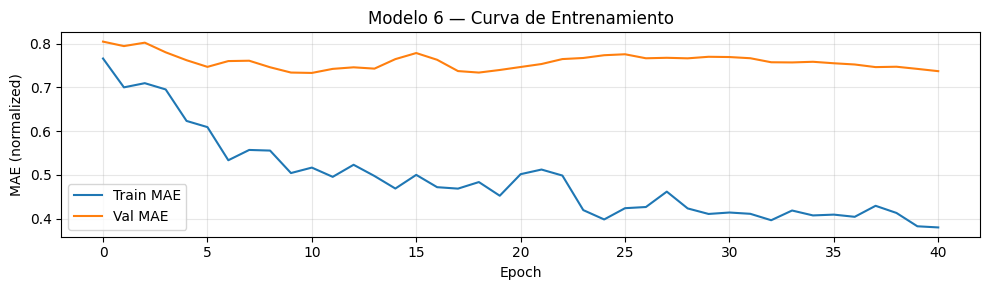

In [125]:
y6_pred_s = model_main.predict(X_test_s).flatten()
y6_pred   = scaler_y.inverse_transform(y6_pred_s.reshape(-1,1)).flatten()
results.append(evaluate('LSTM+TDA v2+Exog+Attention (Modelo 6)', y_test, y6_pred))

# Training curve
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(history_main.history['loss'],     label='Train MAE')
ax.plot(history_main.history['val_loss'], label='Val MAE')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE (normalized)')
ax.set_title('Modelo 6 — Curva de Entrenamiento')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## §6 — Modelo 7: LightGBM + TDA v2 + Exógenas

Input aplanado: 12 timesteps × N_FEATURES = 12·N_FEATURES columnas.  
LightGBM no necesita secuencias temporales — ve toda la ventana como vector flat.

In [126]:
# ── Model 7: LightGBM ─────────────────────────────────────
X_lgb_train = X_train.reshape(n_train, -1)              # (117, 12*N_FEATURES)
X_lgb_val   = X_val.reshape(len(X_val), -1)
X_lgb_test  = X_test.reshape(len(X_test), -1)

dtrain = lgb.Dataset(X_lgb_train, label=y_train)
dval   = lgb.Dataset(X_lgb_val,   label=y_val, reference=dtrain)

params = {
    'objective':       'regression_l1',   # MAE loss
    'metric':          'mae',
    'learning_rate':   0.05,
    'num_leaves':      31,
    'min_child_samples': 10,
    'subsample':       0.8,
    'colsample_bytree': 0.8,
    'random_state':    42,
    'verbose':         -1,
}

lgb_model = lgb.train(
    params,
    dtrain,
    num_boost_round=500,
    valid_sets=[dval],
    callbacks=[
        lgb.early_stopping(stopping_rounds=30, verbose=False),
        lgb.log_evaluation(period=50)
    ]
)

y7_pred = lgb_model.predict(X_lgb_test)
results.append(evaluate('LightGBM+TDA v2+Exog (Modelo 7)', y_test, y7_pred))
print(f"Best iteration: {lgb_model.best_iteration}")

[50]	valid_0's l1: 32.9272
[100]	valid_0's l1: 32.4641
── LightGBM+TDA v2+Exog (Modelo 7) ────────────────────────────────────────
  MAE : 39.0132
  RMSE: 49.6387
  R²  : 0.2443
Best iteration: 89


## §7 — Tabla Comparativa y Predicciones en Conjunto de Prueba


   ABLATION STUDY — Conjunto de Prueba
                                          MAE    RMSE     R²
Model                                                       
LSTM+TDA v2+Exog+Attention (Modelo 6) 29.1069 38.6295 0.5424
LSTM+TDA v1 (Sesion-6)                29.4890 37.5017 0.5687
LSTM+TDA v2 sin exog (Modelo 5)       32.9996 43.0317 0.4321
LSTM puro (Modelo 2)                  34.3823 46.3652 0.3407
RF (Sesion-6 baseline)                38.7105 48.9645 0.2647
LightGBM+TDA v2+Exog (Modelo 7)       39.0132 49.6387 0.2443
LSTM+Exógenas sin TDA (Modelo 4)      45.6941 56.4913 0.0213


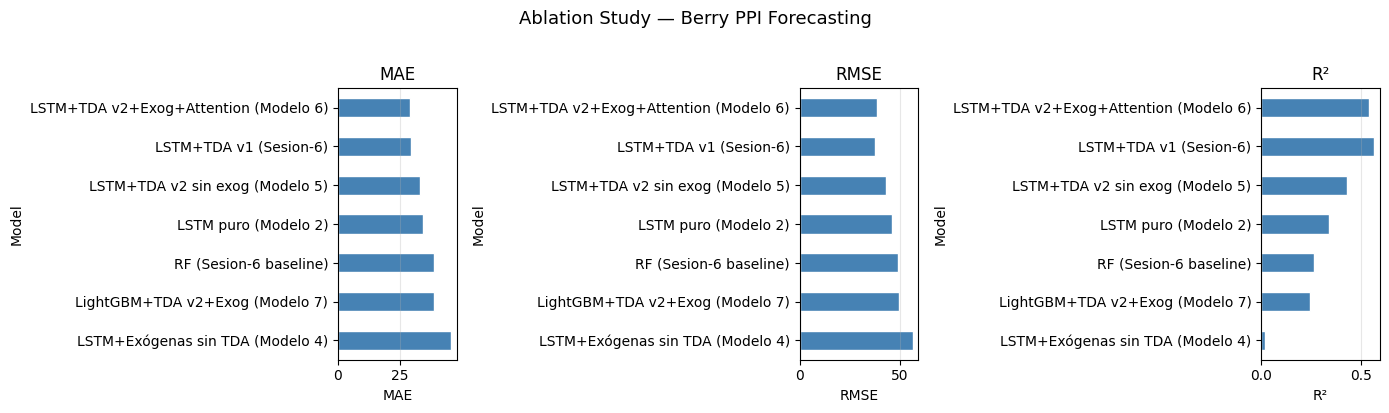

In [127]:
df_results = pd.DataFrame(results).set_index('Model')
df_results = df_results.sort_values('MAE')

print("\n" + "="*65)
print("   ABLATION STUDY — Conjunto de Prueba")
print("="*65)
print(df_results.to_string(float_format='{:.4f}'.format))
print("="*65)

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['MAE', 'RMSE', 'R²']):
    df_results[col].plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
plt.suptitle('Ablation Study — Berry PPI Forecasting', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

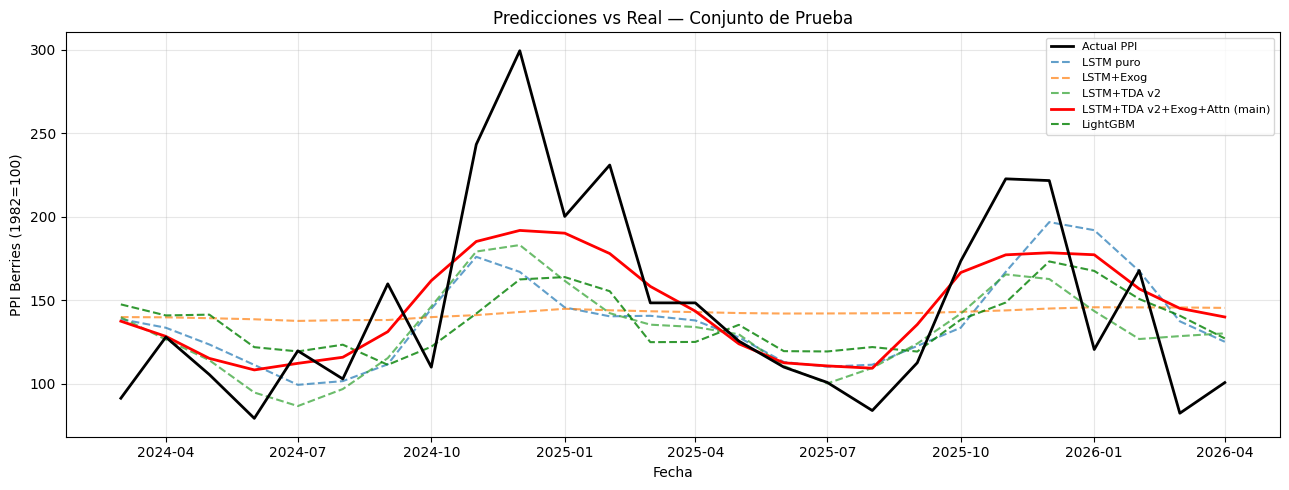

In [128]:
# Forecast vs actual on test set (all models)
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test_dates, y_test,  'k-', linewidth=2, label='Actual PPI', zorder=5)
ax.plot(test_dates, y2_pred, '--', alpha=0.7, label='LSTM puro')
ax.plot(test_dates, y4_pred, '--', alpha=0.7, label='LSTM+Exog')
ax.plot(test_dates, y5_pred, '--', alpha=0.7, label='LSTM+TDA v2')
ax.plot(test_dates, y6_pred, 'r-', linewidth=2, label='LSTM+TDA v2+Exog+Attn (main)', zorder=4)
ax.plot(test_dates, y7_pred, 'g--', alpha=0.8, label='LightGBM')
ax.set_xlabel('Fecha')
ax.set_ylabel('PPI Berries (1982=100)')
ax.set_title('Predicciones vs Real — Conjunto de Prueba')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## §8 — Importancia de Features: SHAP sobre LightGBM

SHAP revela qué variables (exógenas y TDA) impulsan más las predicciones.

In [129]:
# Build feature names matching flattened (12, N_FEATURES) input
tda_names_single = (
    ['price_t'] +
    [f'PE_H{d}' for d in range(3)] +
    [f'Amp_H{d}' for d in range(3)] +
    ['maxH1'] +
    [f'Betti_H0_b{i}' for i in range(10)] +
    [f'Betti_H1_b{i}' for i in range(10)] +
    ['Wass_H0', 'Wass_H1'] +
    ['H1_count_p75'] +
    [f'emb_{i}' for i in range(EMBED_PTS * D)]
)   # 157 names

exog_names = list(df_exog.columns)   # N_EXOG names
feature_names_single = tda_names_single + exog_names   # 157 + N_EXOG

# Replicate for L=12 timesteps
feature_names_flat = [f't{t}_{name}'
                      for t in range(L)
                      for name in feature_names_single]
print(f"Total flat feature names: {len(feature_names_flat)} (expect {L*N_FEATURES})")

Total flat feature names: 1896 (expect 1896)


Top-20 most important features:
       feature  mean_abs_shap
     t0_emb_15       3.893112
      t0_emb_9       2.915108
    t0_emb_119       2.495097
      t0_emb_4       1.994989
    t0_price_t       1.628214
   t11_price_t       1.266528
t7_Betti_H0_b7       1.234073
     t0_emb_26       1.228178
    t5_Wass_H0       1.194602
    t1_price_t       1.121572
     t7_Amp_H1       1.106242
     t0_emb_53       1.096066
     t0_emb_17       1.062806
      t0_emb_8       1.037927
     t0_emb_70       0.953170
    t8_Wass_H1       0.952622
    t1_Wass_H0       0.852441
    t1_emb_113       0.848252
    t0_emb_107       0.749473
     t0_emb_11       0.721433


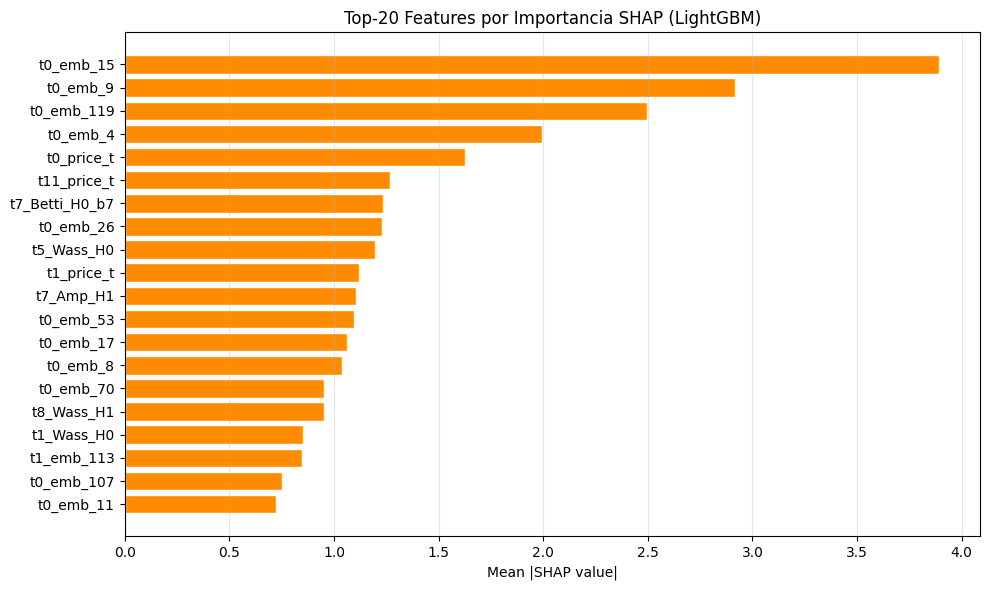


Importancia por grupo:
group
RawTakens             29.822450
BettiCurve             6.803022
Wasserstein            6.536870
TDA_scalar             5.781317
Amplitude              2.792638
PersistenceEntropy     2.562490
SP500                  0.947354


In [130]:
explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_lgb_test)     # (n_test, L*N_FEATURES)

# Mean absolute SHAP per feature (aggregate across timesteps)
mean_shap = np.abs(shap_values).mean(axis=0)        # (L*N_FEATURES,)
shap_df = pd.DataFrame({
    'feature': feature_names_flat,
    'mean_abs_shap': mean_shap
}).sort_values('mean_abs_shap', ascending=False)

print("Top-20 most important features:")
print(shap_df.head(20).to_string(index=False))

# Plot top-20
top20 = shap_df.head(20)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top20['feature'][::-1], top20['mean_abs_shap'][::-1],
        color='darkorange', edgecolor='white')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Top-20 Features por Importancia SHAP (LightGBM)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Aggregate importance by feature group
def group_name(fname):
    n = fname.split('_', 1)[1]   # strip t{k}_ prefix
    if n in ('PE_H0', 'PE_H1', 'PE_H2'):                    return 'PersistenceEntropy'
    if n in ('Amp_H0', 'Amp_H1', 'Amp_H2'):                 return 'Amplitude'
    if n.startswith('Betti_H0') or n.startswith('Betti_H1'): return 'BettiCurve'
    if n in ('Wass_H0', 'Wass_H1'):                          return 'Wasserstein'
    if n.startswith('emb_'):                                  return 'RawTakens'
    if n in ('maxH1', 'H1_count_p75', 'price_t'):            return 'TDA_scalar'
    return n   # exog series name

shap_df['group'] = shap_df['feature'].apply(group_name)
group_importance = shap_df.groupby('group')['mean_abs_shap'].sum().sort_values(ascending=False)
print("\nImportancia por grupo:")
print(group_importance.to_string())

## §9 — Preguntas de Análisis

1. **¿TDA v2 mejora sobre TDA v1?** Compara Modelo 3 (LSTM+TDA v1, MAE=29.49) vs Modelo 5 (LSTM+TDA v2). ¿H₂, Wasserstein y count H₁ añaden señal real?

2. **¿Las exógenas añaden valor sobre TDA solo?** Compara Modelo 5 (TDA v2 solo) vs Modelo 6 (TDA v2 + exog + attention). ¿Cuánto baja el MAE?

3. **¿Qué exógena domina en SHAP?** Revisa `group_importance`. ¿Es S&P500, CPI, o alguna serie agrícola?

4. **¿El mecanismo de attention ayuda?** Para N=168 secuencias de entrenamiento, los modelos grandes pueden sobreajustar. Compara curvas de entrenamiento de Modelo 5 vs 6.

5. **¿LightGBM supera al LSTM?** Con N pequeño, gradient boosting suele ser más estable. ¿Se cumple aquí?